<a href="https://colab.research.google.com/github/tzmjoseph/UT_Austin_PGP_AIML_Projects/blob/main/ThomasJoseph_PYF_Project_Learner_Notebook_Full_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project Python Foundations: FoodHub Data Analysis

### Context

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. Online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub offers access to multiple restaurants through a single smartphone app.

The app allows the restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirms the pick-up in the app and travels to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin of the delivery order from the restaurants.

### Objective

The food aggregator company has stored the data of the different orders made by the registered customers in their online portal. They want to analyze the data to get a fair idea about the demand of different restaurants which will help them in enhancing their customer experience. Suppose you are hired as a Data Scientist in this company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company to improve the business.

### Data Description

The data contains the different data related to a food order. The detailed data dictionary is given below.

### Data Dictionary

* order_id: Unique ID of the order
* customer_id: ID of the customer who ordered the food
* restaurant_name: Name of the restaurant
* cuisine_type: Cuisine ordered by the customer
* cost_of_the_order: Cost of the order
* day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
* rating: Rating given by the customer out of 5
* food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
* delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

### Let us start by importing the required libraries

In [ ]:
# TJ Below code threw an error
# Installing the libraries with the specified version.
!pip install numpy==1.25.2 pandas==1.5.3 matplotlib==3.7.1 seaborn==0.13.1 -q --user

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 88.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


In [ ]:
# Installing the libraries with the specified version.
# !pip install numpy==2.0.2 pandas==2.2.2 matplotlib==3.10.0 seaborn==0.13.2 -q --user

**Note**:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in ***this notebook***.

In [ ]:
# import libraries for data manipulation
import numpy as np
import pandas as pd

# import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

### Understanding the structure of the data

In [ ]:
# uncomment and run the below code snippets if the dataset is present in the Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Write your code here to read the data
food_hub_data = pd.read_csv("/content/drive/MyDrive/Learning/UT Austin/Python/Project/foodhub_order.csv")
# Create working copy of data frame to use for analysis
food_hub_data_working_copy = food_hub_data.copy()

In [ ]:
# Write your code here to view the first 5 rows
food_hub_data_working_copy.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


### **Question 1:** How many rows and columns are present in the data? [0.5 mark]

In [ ]:
# Write your code here
print("The Food Hub ordering data has", food_hub_data_working_copy.shape[0], "rows and", food_hub_data_working_copy.shape[1], "columns.")

The Food Hub ordering data has 1898 rows and 9 columns.


#### Observations:
The **Food Hub** ordering data has:
*   1898 rows
*   9 columns

\
The 9 columns are as follows:


*   Order ID - order_id
*   Customer ID - customer_id
*   Restaurant Name - restaurant_name
*   Cuisine Type - cuisine_type
*   Cost of the Order - cost_of_the_order
*   Day of the Week - day_of_the_week
*   Rating - rating
*   Food Preparation Time - food_preparation_time
*   Delivery Time - delivery_time








### **Question 2:** What are the datatypes of the different columns in the dataset? (The info() function can be used) [0.5 mark]

In [ ]:
# Write your code here
food_hub_data_working_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


#### Observations:


*   The dataset has 9 data elements [Order ID, Customer ID, Restaurant Name, Cuisine Type, Cost of the Order, Day of the Week, Rating, Food Preparation Time, Delivery Time] for each order.
*   Four of the data elements [Order ID, Customer ID, Food Preparation Time, Delivery Time] are integer (int64).
*   One of the data elements [Cost of the Order] is a decimal / float (float64)
*   Four data elements [Restaurant Name, Cuisine Type, Day of the Week, Rating] are objects.





### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method. [1 mark]

In [ ]:
# Write your code here
food_hub_data_working_copy.isna().any()

,0
order_id,False
customer_id,False
restaurant_name,False
cuisine_type,False
cost_of_the_order,False
day_of_the_week,False
rating,False
food_preparation_time,False
delivery_time,False


In [ ]:
# Checking if order_id has all unique values
food_hub_data_working_copy['order_id'].nunique()

1898

In [ ]:
# Confirming that order_id does not have any NA / Not a Number values
food_hub_data_working_copy[food_hub_data_working_copy['order_id'].isna()]

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time


In [ ]:
# Confirming that customer_id does not have any NA / Not a Number values
food_hub_data_working_copy[food_hub_data_working_copy['customer_id'].isna()]

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time


In [ ]:
# Confirming that restaurant_name does not have any NA / Not a Number values
food_hub_data_working_copy[food_hub_data_working_copy['restaurant_name'].isna()]

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time


In [ ]:
# Confirming that cuisine_type does not have any NA / Not a Number values
food_hub_data_working_copy[food_hub_data_working_copy['cuisine_type'].isna()]

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time


In [ ]:
# Confirming that cost_of_the_order does not have any NA / Not a Number values
food_hub_data_working_copy[food_hub_data_working_copy['cost_of_the_order'].isna()]

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time


In [ ]:
# Confirming that day_of_the_week does not have any NA / Not a Number values
food_hub_data_working_copy[food_hub_data_working_copy['day_of_the_week'].isna()]

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time


In [ ]:
# Confirming that rating does not have any NA / Not a Number values
food_hub_data_working_copy[food_hub_data_working_copy['rating'].isna()]

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time


In [ ]:
# Confirming that food_preparation_time does not have any NA / Not a Number values
food_hub_data_working_copy[food_hub_data_working_copy['food_preparation_time'].isna()]

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time


In [ ]:
# Confirming that delivery_time does not have any NA / Not a Number values
food_hub_data_working_copy[food_hub_data_working_copy['delivery_time'].isna()]

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time


#### Observations:
*   There are no null values as can be seen when running the info method on the data frame.
*   There are no NA or Not a Number values in any of the columns in the data.



### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed? [2 marks]

In [ ]:
# Write your code here
food_hub_data_working_copy.describe()

,order_id,customer_id,cost_of_the_order,food_preparation_time,delivery_time
count,1.898000e+03,1898.000000,1898.000000,1898.000000,1898.000000
mean,1.477496e+06,171168.478398,16.498851,27.371970,24.161749
std,5.480497e+02,113698.139743,7.483812,4.632481,4.972637
min,1.476547e+06,1311.000000,4.470000,20.000000,15.000000
25%,1.477021e+06,77787.750000,12.080000,23.000000,20.000000
50%,1.477496e+06,128600.000000,14.140000,27.000000,25.000000
75%,1.477970e+06,270525.000000,22.297500,31.000000,28.000000
max,1.478444e+06,405334.000000,35.410000,35.000000,33.000000


In [ ]:
# Add a new column for the total order time that is sum of food preparation time and delivery time and describe statistics
food_hub_data_working_copy['total_order_time'] = food_hub_data_working_copy['food_preparation_time'] + food_hub_data_working_copy['delivery_time']
food_hub_data_working_copy.describe()

,order_id,customer_id,cost_of_the_order,food_preparation_time,delivery_time,total_order_time
count,1.898000e+03,1898.000000,1898.000000,1898.000000,1898.000000,1898.000000
mean,1.477496e+06,171168.478398,16.498851,27.371970,24.161749,51.533720
std,5.480497e+02,113698.139743,7.483812,4.632481,4.972637,6.833603
min,1.476547e+06,1311.000000,4.470000,20.000000,15.000000,35.000000
25%,1.477021e+06,77787.750000,12.080000,23.000000,20.000000,47.000000
50%,1.477496e+06,128600.000000,14.140000,27.000000,25.000000,52.000000
75%,1.477970e+06,270525.000000,22.297500,31.000000,28.000000,56.000000
max,1.478444e+06,405334.000000,35.410000,35.000000,33.000000,68.000000


#### Observations:


*   The average cost of the order is $16.50
*   The average time taken to prepare the food once the order is placed is 27.37 minutes
*   The average time taken to deliver the food once it is ready is 24.16 minutes
*   The average time taken from placing the order to delivering the food to the customer is 51.53 minutes




### **Question 5:** How many orders are not rated? [1 mark]

In [ ]:
# Write the code here
# How many unique values in the rating column
food_hub_data_working_copy['rating'].nunique()

4

In [ ]:
# What are the unique values in the rating column
print(food_hub_data_working_copy['rating'].unique())

['Not given' '5' '3' '4']


In [ ]:
# Checking how many ratings have value 'Not given'
not_given_rating_orders = food_hub_data_working_copy[food_hub_data_working_copy['rating'] == 'Not given']
print("The data has", not_given_rating_orders.shape[0], "orders that are not rated.")

The data has 736 orders that are not rated.


#### Observations:


*   The ratings column has 4 unique values = 3, 4, 5, Not given
*   Tere are 736 orders that are not rated.



### Exploratory Data Analysis (EDA)

### Univariate Analysis

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) [9 marks]

The data has 1200 unique customers.

The data has 178 unique restaurants.



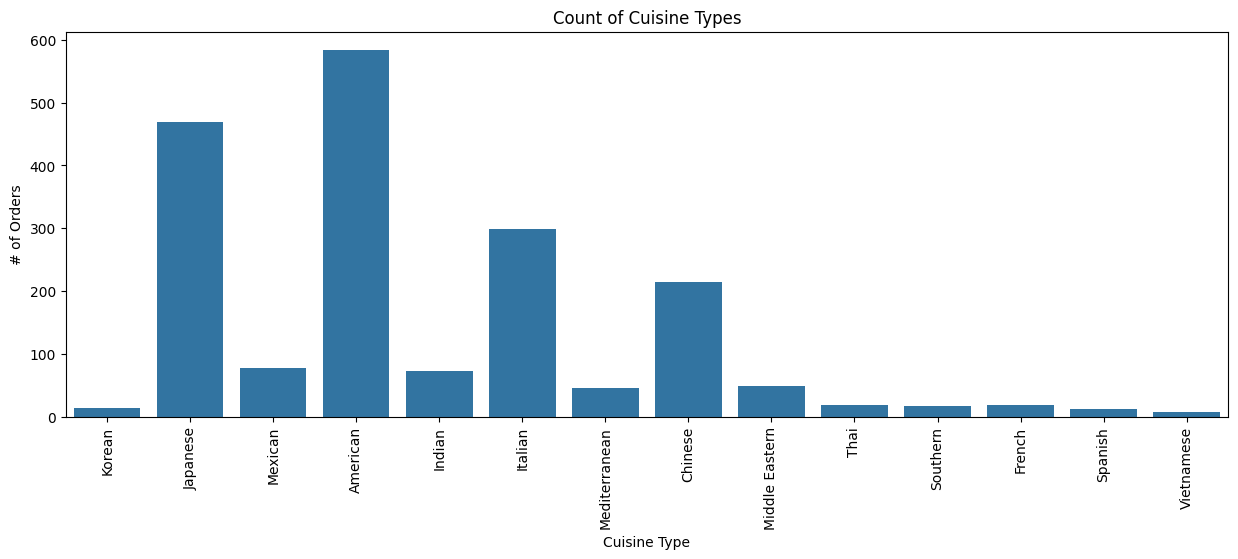

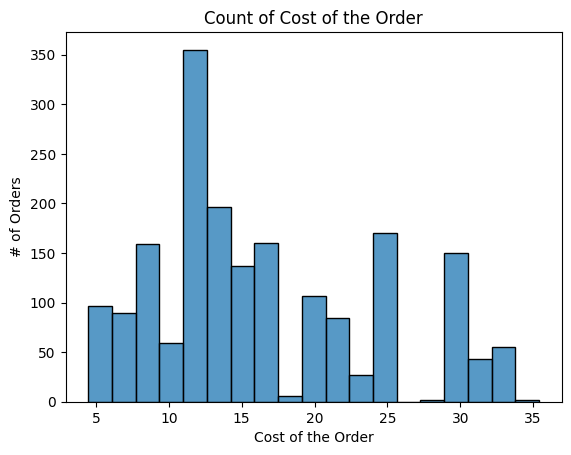

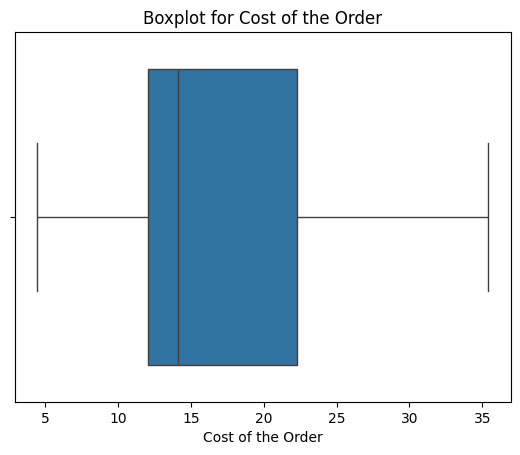


Unique values for the Day of the Week:
['Weekend' 'Weekday']



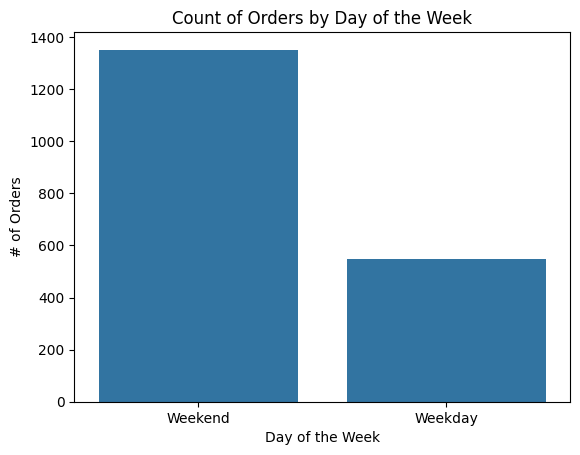

Unique values for Rating:
['Not given' '5' '3' '4']



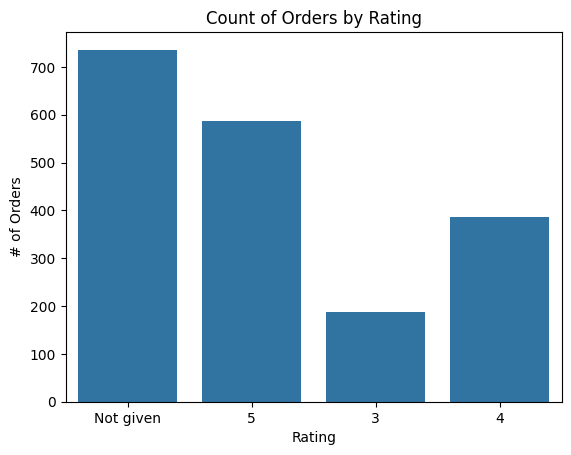

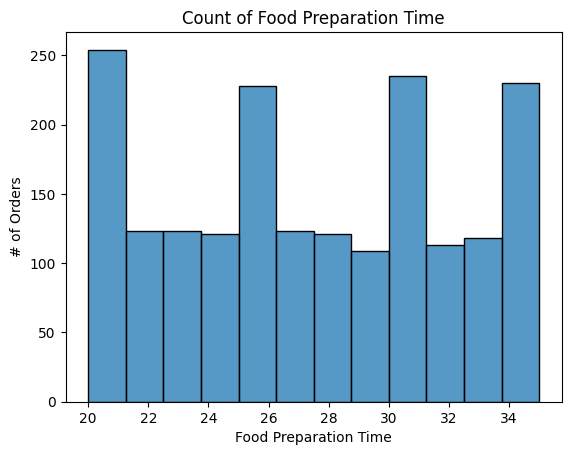

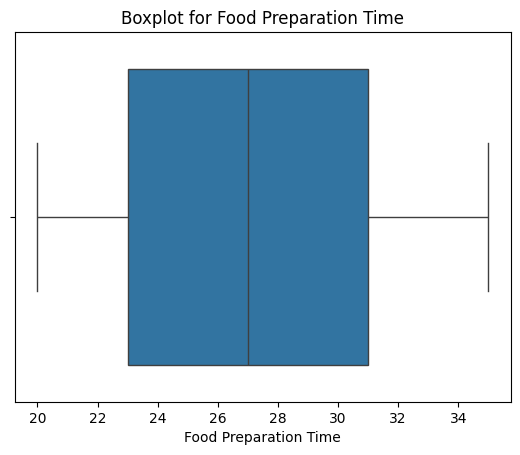

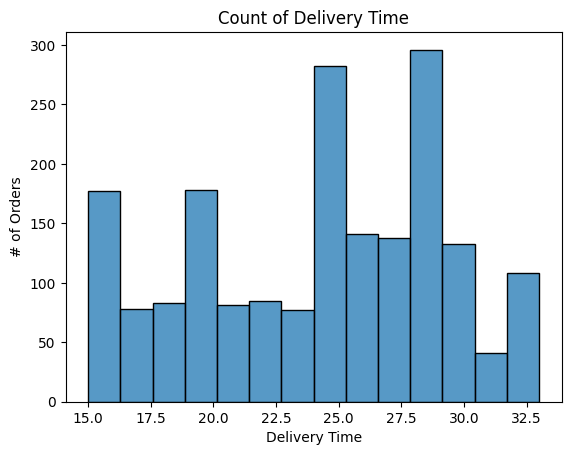

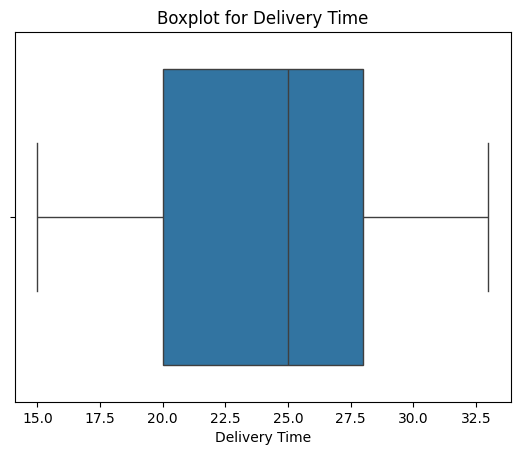

In [ ]:
# Write the code here

# Checking for the count of unique customers
print("The data has", food_hub_data_working_copy['customer_id'].nunique(), "unique customers.")
print() # Printing blank line for spacing in output. Makes for better readability.

# Chceking for the count of unique restaurants
print("The data has", food_hub_data_working_copy['restaurant_name'].nunique(), "unique restaurants.")
print() # Printing blank line for spacing in output. Makes for better readability.

plt.figure(figsize=(15, 5))

#Cuisine Type
sns.countplot(data=food_hub_data_working_copy, x='cuisine_type')
plt.title('Count of Cuisine Types')
plt.xlabel('Cuisine Type')
plt.ylabel('# of Orders')
plt.xticks(rotation=90)
plt.show()
print() # Printing blank line for spacing in output. Makes for better readability.

# Cost of the Order
sns.histplot(data=food_hub_data_working_copy,x='cost_of_the_order')
plt.title('Count of Cost of the Order')
plt.xlabel('Cost of the Order')
plt.ylabel('# of Orders')
plt.show()
print() # Printing blank line for spacing in output. Makes for better readability.
sns.boxplot(data=food_hub_data_working_copy,x='cost_of_the_order')
plt.title('Boxplot for Cost of the Order')
plt.xlabel('Cost of the Order')
plt.show()
print()

# Day of the Week
print("Unique values for the Day of the Week:")
print(food_hub_data_working_copy['day_of_the_week'].unique())
print() # Printing blank line for spacing in output. Makes for better readability.
sns.countplot(data=food_hub_data_working_copy, x='day_of_the_week')
plt.title('Count of Orders by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('# of Orders')
plt.show()

# Rating
print("Unique values for Rating:")
print(food_hub_data_working_copy['rating'].unique())
print() # Printing blank line for spacing in output. Makes for better readability.
sns.countplot(data=food_hub_data_working_copy, x='rating')
plt.title('Count of Orders by Rating')
plt.xlabel('Rating')
plt.ylabel('# of Orders')
plt.show()

# Food Preparation Time
sns.histplot(data=food_hub_data_working_copy,x='food_preparation_time')
plt.title('Count of Food Preparation Time')
plt.xlabel('Food Preparation Time')
plt.ylabel('# of Orders')
plt.show()
print() # Printing blank line for spacing in output. Makes for better readability
sns.boxplot(data=food_hub_data_working_copy,x='food_preparation_time')
plt.title('Boxplot for Food Preparation Time')
plt.xlabel('Food Preparation Time')
plt.show()
print() # Printing blank line for spacing in output. Makes for better readability

# Delivery Time
sns.histplot(data=food_hub_data_working_copy,x='delivery_time')
plt.title('Count of Delivery Time')
plt.xlabel('Delivery Time')
plt.ylabel('# of Orders')
plt.show()
print() # Printing blank line for spacing in output. Makes for better readability
sns.boxplot(data=food_hub_data_working_copy,x='delivery_time')
plt.title('Boxplot for Delivery Time')
plt.xlabel('Delivery Time')
plt.show()
print() # Printing blank line for spacing in output. Makes for better readability


### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received? [1 mark]

In [ ]:
# Write the code here
food_hub_data_working_copy['restaurant_name'].value_counts().head()

,count
restaurant_name,
Shake Shack,219
The Meatball Shop,132
Blue Ribbon Sushi,119
Blue Ribbon Fried Chicken,96
Parm,68


#### Observations:

The top 5 restaurants in terms of orders placed are as given below.


1.   Shake Shack - 219 orders
2.   The Meatball Shop - 132 orders
3.   Blue Ribbon Sushi - 119 orders
4.   Blue Ribbon Fried Chicken - 96 orders
5.   Parm - 68 orders


### **Question 8**: Which is the most popular cuisine on weekends? [1 mark]

In [ ]:
# Write the code here
food_hub_data_working_copy[food_hub_data_working_copy['day_of_the_week'] == 'Weekend']['cuisine_type'].value_counts()[:1]

,count
cuisine_type,
American,415


#### Observations:


*   The most popular cuisine on weekends is American.


### **Question 9**: What percentage of the orders cost more than 20 dollars? [2 marks]

In [ ]:
# Write the code here
print("The percentage of food that costs more than 20 dollars is", round((food_hub_data_working_copy[food_hub_data_working_copy['cost_of_the_order'] > 20].shape[0] / food_hub_data_working_copy.shape[0] * 100), 2), "%")

The percentage of food that costs more than 20 dollars is 29.24 %


#### Observations:


*   The percentage of food that costs more than 20 dollars is 29.24%


### **Question 10**: What is the mean order delivery time? [1 mark]

In [ ]:
# Write the code here
mean = food_hub_data_working_copy['delivery_time'].mean()
print("The mean delivery time for an order is", round(mean, 2), "minutes")

The mean delivery time for an order is 24.16 minutes


#### Observations:


*   The mean delivery time for an order is 24.16 minutes.



### **Question 11:** The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

In [ ]:
# Write the code here
food_hub_data_working_copy['customer_id'].value_counts().head(3)

,count
customer_id,
52832,13
47440,10
83287,9


#### Observations:

The below lists the top 3 customers by order placed who should receive the 20% discount vouchers.
*   52832
*   47440
*   83287



### Multivariate Analysis

### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) [10 marks]


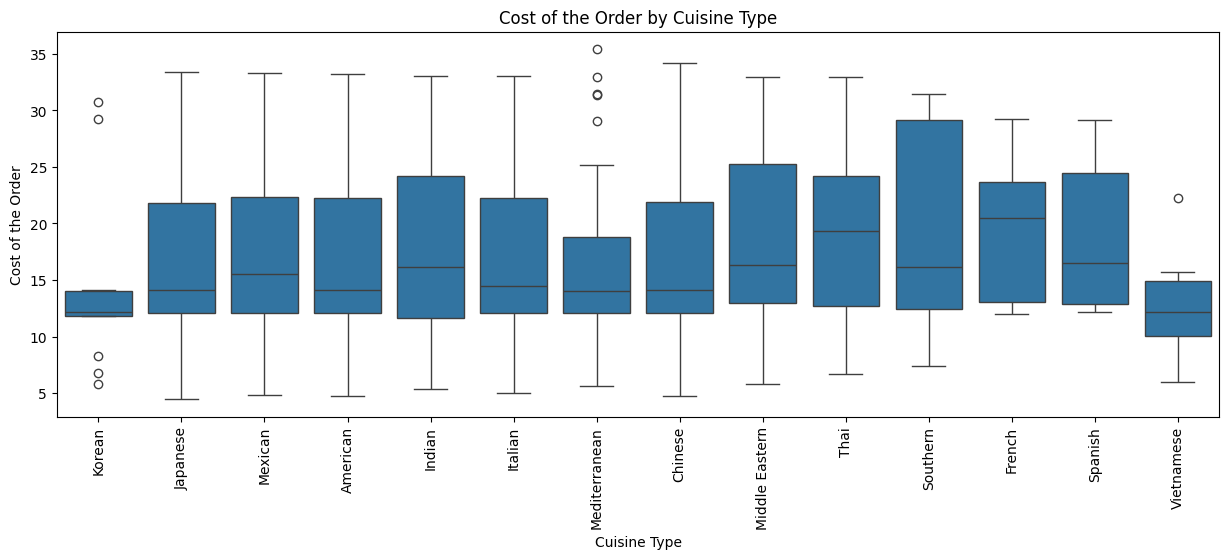

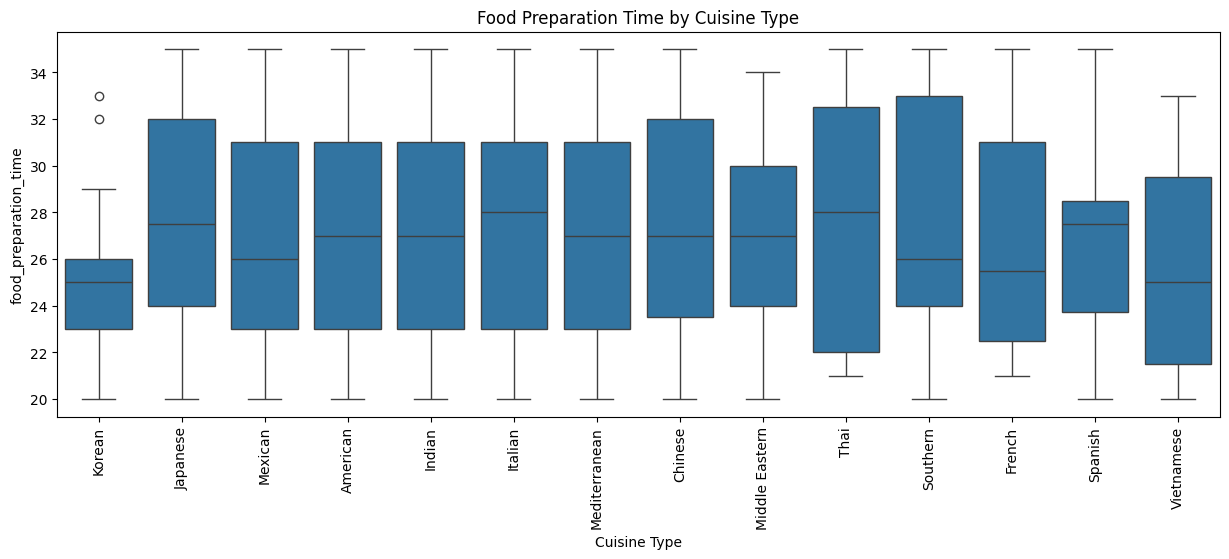

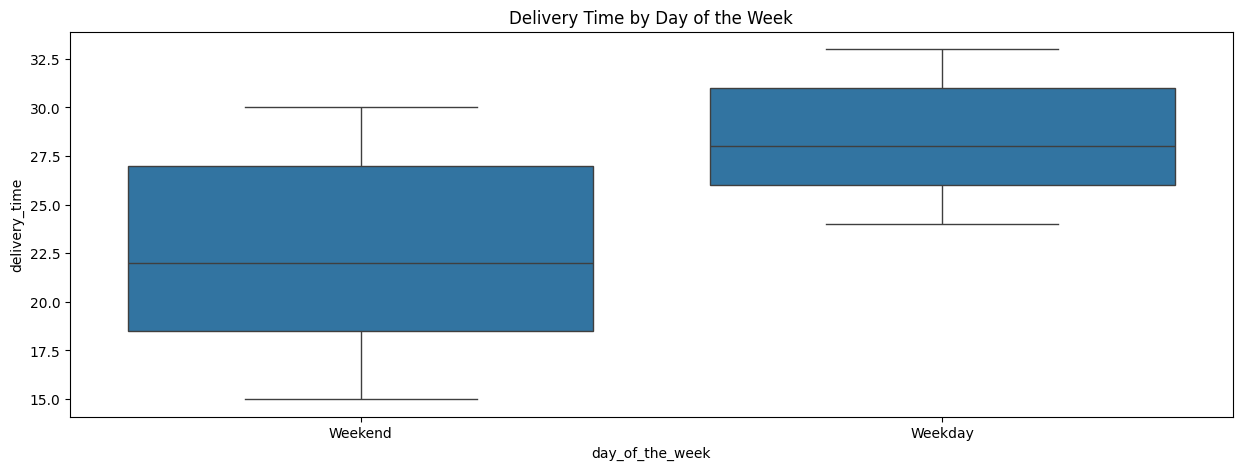

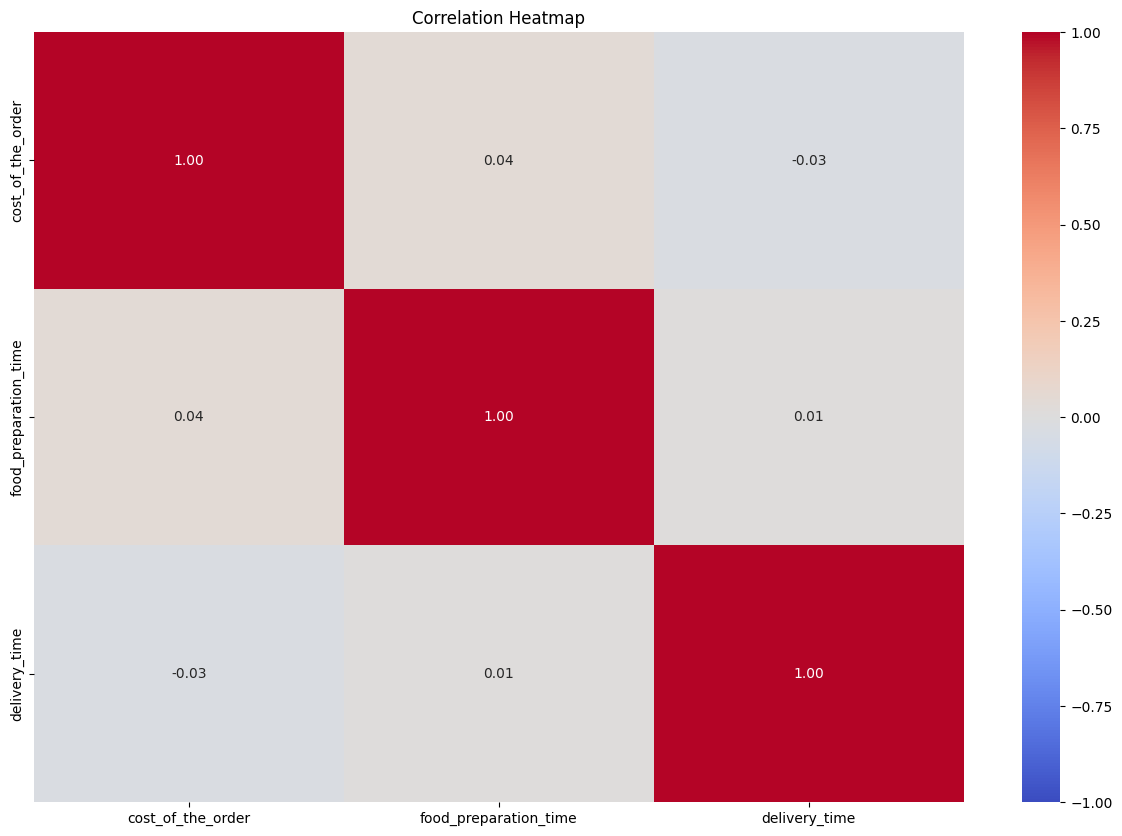

In [ ]:
# Write the code here
# Check relationship between cuisine and cost of the order
plt.figure(figsize=(15, 5))
sns.boxplot(data=food_hub_data_working_copy, x='cuisine_type', y='cost_of_the_order')
plt.xticks(rotation=90)
plt.title('Cost of the Order by Cuisine Type')
plt.xlabel('Cuisine Type')
plt.ylabel('Cost of the Order')
plt.show()
print() # Printing blank line for spacing in output. Makes for better readability

# Check relationship between cuisine and food preparation time
plt.figure(figsize=(15, 5))
sns.boxplot(data=food_hub_data_working_copy, x='cuisine_type', y='food_preparation_time')
plt.xticks(rotation=90)
plt.title('Food Preparation Time by Cuisine Type')
plt.xlabel('Cuisine Type')

# Check relationship between day of the week and delivery time
plt.figure(figsize=(15, 5))
sns.boxplot(data=food_hub_data_working_copy, x='day_of_the_week', y='delivery_time')
plt.title('Delivery Time by Day of the Week')

# Plotting heatmap
plt.figure(figsize=(15, 10))
columns = ['cost_of_the_order', 'food_preparation_time', 'delivery_time']
sns.heatmap(food_hub_data_working_copy[columns].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer. [3 marks]

In [ ]:
# Write the code here
orders_with_rating = food_hub_data_working_copy[food_hub_data_working_copy['rating'] != 'Not given']
orders_with_rating['numeric_rating'] = pd.to_numeric(orders_with_rating['rating'])
restaurants_rating_count_mean = orders_with_rating.groupby('restaurant_name').agg({'numeric_rating': ['count', 'mean']})
restaurants_rating_count_mean.columns = ['rating_count', 'rating_mean']
restaurants_rating_count_mean = restaurants_rating_count_mean.reset_index()
restaurants_rating_count_mean[(restaurants_rating_count_mean['rating_count'] > 50) & (restaurants_rating_count_mean['rating_mean'] > 4)]

/tmp/ipython-input-1622053249.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  orders_with_rating['numeric_rating'] = pd.to_numeric(orders_with_rating['rating'])


,restaurant_name,rating_count,rating_mean
16,Blue Ribbon Fried Chicken,64,4.328125
17,Blue Ribbon Sushi,73,4.219178
117,Shake Shack,133,4.278195
132,The Meatball Shop,84,4.511905


#### Observations:
The approach I took here was to create a dataframe that did not include orders where the ratiing was 'Not given'. Using this new data frame I created another data frame that only had the restautant names with the count of their order and the average rating. The last statement is to filter out only those retaurants  that have an order count greater than 50 and an average rating greater than 4.

\
There are 4 restaurants that meet this criteria.
*   Blue Ribbon Fried Chicken
*   Blue Ribbon Sushi
*   Shake Shack
*   The Meatball Shop



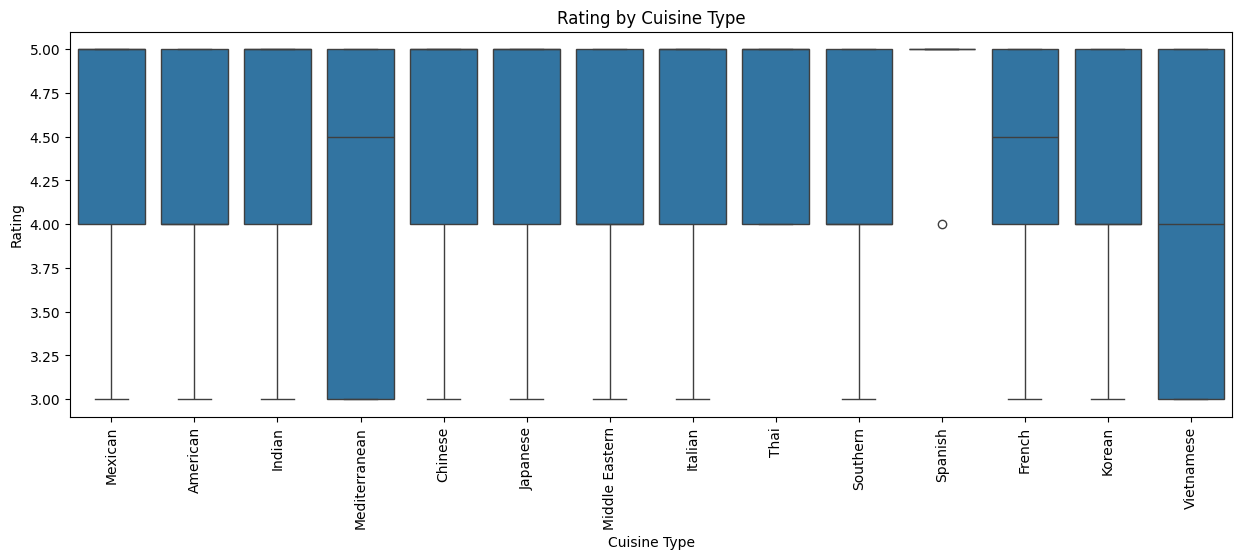

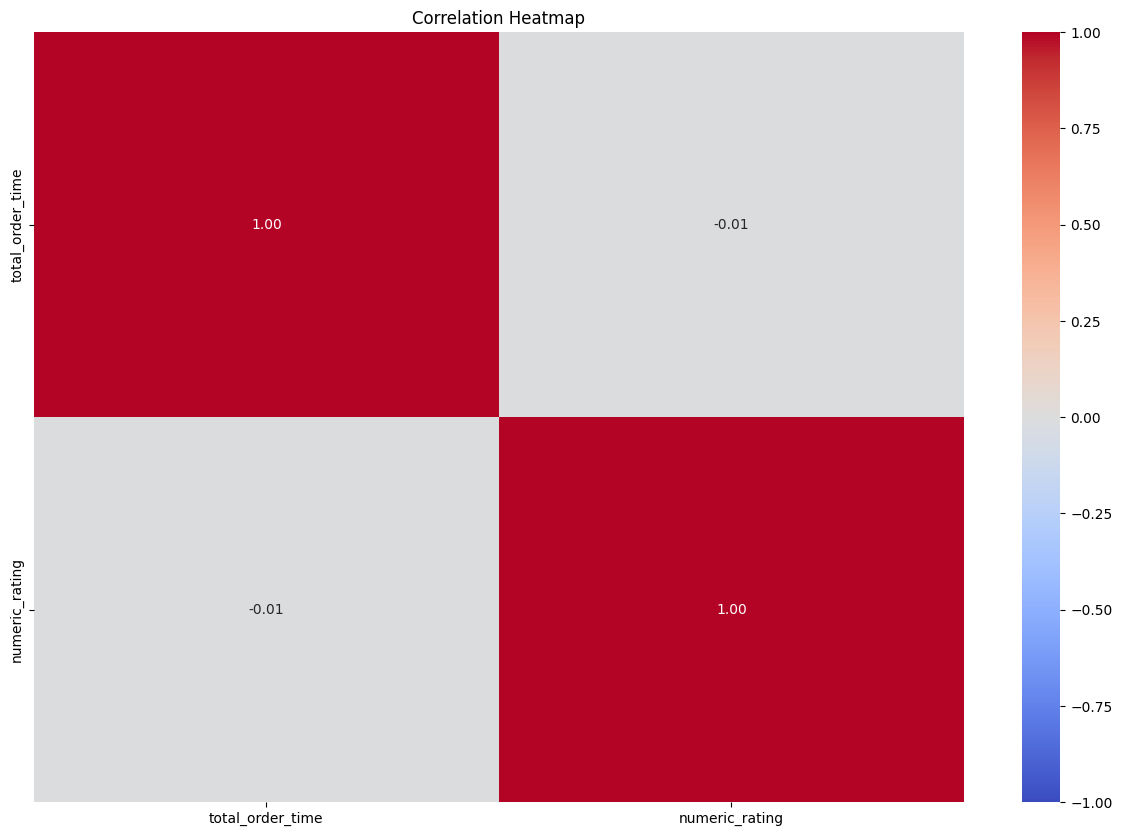

In [ ]:
# Check relationship between cuisine and rating
plt.figure(figsize=(15, 5))
sns.boxplot(data=orders_with_rating, x='cuisine_type', y='numeric_rating')
plt.xticks(rotation=90)
plt.title('Rating by Cuisine Type')
plt.xlabel('Cuisine Type')
plt.ylabel('Rating')
print() # Printing blank line for spacing in output. Makes for better readability

# Plotting heatmap
plt.figure(figsize=(15, 10))
columns = ['total_order_time', 'numeric_rating']
sns.heatmap(orders_with_rating[columns].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
cuisine_rating = orders_with_rating.groupby('cuisine_type').agg({'numeric_rating': ['count', 'mean']})
cuisine_rating.columns = ['rating_count', 'rating_mean']
cuisine_rating = cuisine_rating.reset_index()
print(cuisine_rating.sort_values(by='rating_mean', ascending=False))
print()
print(cuisine_rating.sort_values(by='rating_count', ascending=False))

      cuisine_type  rating_count  rating_mean
11         Spanish             6     4.833333
12            Thai             9     4.666667
3           Indian            50     4.540000
8          Mexican            48     4.416667
5         Japanese           273     4.373626
4          Italian           172     4.360465
1          Chinese           133     4.338346
10        Southern            13     4.307692
2           French            10     4.300000
0         American           368     4.298913
9   Middle Eastern            34     4.235294
7    Mediterranean            32     4.218750
6           Korean             9     4.111111
13      Vietnamese             5     4.000000

      cuisine_type  rating_count  rating_mean
0         American           368     4.298913
5         Japanese           273     4.373626
4          Italian           172     4.360465
1          Chinese           133     4.338346
3           Indian            50     4.540000
8          Mexican            48 

### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders. [3 marks]

In [ ]:
# Write the code here
def calculate_net_revenue(row):
    if row['cost_of_the_order'] > 20:
        return round((row['cost_of_the_order'] * 0.25), 2)

    elif row['cost_of_the_order'] > 5:
        return round((row['cost_of_the_order'] * 0.15), 2)

    else:
        return 0.00

food_hub_data_working_copy['net_revenue'] = food_hub_data_working_copy.apply(calculate_net_revenue, axis=1)

print("The net revenue generated by the company across all orders is $", food_hub_data_working_copy['net_revenue'].sum())

The net revenue generated by the company across all orders is $ 6166.5


#### Observations:
I created a custom function to calculate the net revenue per order and applied it to the dataframe and then summed up the value from this new column to calculate the total net revenue across all orders.
*   The total net revenue across all orders is $6166.50.

\
**Interesting Observation**
\
I was using an excel to validate the results generated by the Python code against analysis done using an excel and noticed that the total net revenue across all orders calculated by the excel was $0.96 higher than what was calculated by the code. On further analysis I noticed that this was due to the rounded net revenue of an order between excel and the code was off by 1 cent across 96 orders.   




### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.) [2 marks]

In [ ]:
# Write the code here
print("The percentage of orders that take more than 60 minutes to deliver is", round((food_hub_data_working_copy[food_hub_data_working_copy['total_order_time'] > 60].shape[0] / food_hub_data_working_copy.shape[0] * 100), 2), "%")

The percentage of orders that take more than 60 minutes to deliver is 10.54 %


#### Observations:
I had created a new column for calculating the total order time (total_order_time) as part of question 4 so I just used the same in this question to calculate the percentage.

### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends? [2 marks]

In [ ]:
# Write the code here
print("The mean delivery time for weekdays is", round(food_hub_data_working_copy[food_hub_data_working_copy['day_of_the_week'] == 'Weekday']['delivery_time'].mean()), "minutes")
print("The mean delivery time for weekends is", round(food_hub_data_working_copy[food_hub_data_working_copy['day_of_the_week'] == 'Weekend']['delivery_time'].mean()), "minutes")


The mean delivery time for weekdays is 28 minutes
The mean delivery time for weekends is 22 minutes


#### Observations:


*   Average delivery times on weekdays is higher than what it is on weekends.
*   This could be due to greater traffic volumes during weekdays.




### Conclusion and Recommendations

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) [6 marks]

### Conclusions:
*  Most orders fall under the American, Japanese, Italian and Chinese cuisines.
*  Most of the orders are placed during weekends.
*  Delivery times are higher during weekdays.


### Recommendations:

*  Provide more incentives for orders placed during weekdays to increase sales volume.
*  Hire more drivers for weekday deliveries to reduce delivery times.


---

In [ ]:
!jupyter nbconvert "/content/drive/MyDrive/Learning/UT Austin/Python/Project/ThomasJoseph_PYF_Project_Learner_Notebook_Full_Code.ipynb" --to html

[NbConvertApp] Converting notebook /content/drive/MyDrive/Learning/UT Austin/Python/Project/ThomasJoseph_PYF_Project_Learner_Notebook_Full_Code.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 15 image(s).
[NbConvertApp] Writing 945261 bytes to /content/drive/MyDrive/Learning/UT Austin/Python/Project/ThomasJoseph_PYF_Project_Learner_Notebook_Full_Code.html
